Connecting to drive:

In [2]:
import os
import pandas as pd

# Define your local project path ('.' means the current folder where the notebook is saved)
PROJECT_PATH = "C:\\Users\\013ri\\OneDrive\\Documents\\schoolwork\\CyberProject\\CyberSecurityMLproject"
DATASET_PATH = os.path.join(PROJECT_PATH, "datasets/training_data.csv")

# Verify the path
print(f"Project folder set to: {os.path.abspath(PROJECT_PATH)}")
print(f"Dataset path set to: {os.path.abspath(DATASET_PATH)}")

Project folder set to: C:\Users\013ri\OneDrive\Documents\schoolwork\CyberProject\CyberSecurityMLproject
Dataset path set to: C:\Users\013ri\OneDrive\Documents\schoolwork\CyberProject\CyberSecurityMLproject\datasets\training_data.csv


Generating Dataset:

In [3]:
from faker import Faker
import random
import time
import numpy as np


def generate_dataset():
    fake = Faker()
    data = []
    NUM_SAMPLES = 50000

    # --- VOCABULARY ---
    # High Value Signals
    high_exts = [".pem", ".key", ".kdbx", ".xlsx", ".pdf", ".docx", ".wallet", ".sql"]
    high_keywords = [
        "password",
        "budget",
        "secret",
        "salary",
        "invoice",
        "prod_key",
        "backup",
        "private",
        "ssh",
    ]
    high_paths = [
        "C:\\Users\\Admin\\Desktop",
        "C:\\Users\\CEO\\Documents",
        "D:\\Backups",
    ]

    # Junk Signals (Custom lists are still good for System files)
    junk_exts = [".dll", ".sys", ".tmp", ".cache", ".png", ".ico", ".dat", ".bin"]
    junk_paths = [
        "C:\\Windows\\System32",
        "C:\\Program Files",
        "C:\\Users\\Appdata\\Local\\Temp",
    ]
    print("Generating rows...")

    for _ in range(NUM_SAMPLES):
        # 1. Decide Class (95% Junk, 5% Value)
        is_target = random.choices([True, False], weights=[5, 95], k=1)[0]

        if is_target:
            # --- HIGH VALUE GENERATION ---
            # Use Custom Lists to ensure Strong Signal
            base_name = random.choice(high_keywords)
            # Add randomness so they aren't duplicates
            name = f"{base_name}_{random.randint(10,99)}"
            ext = random.choice(high_exts)
            path = random.choice(high_paths)

            # Valuable files are usually somewhat recent
            days_old = random.randint(0, 100)
            label = 1.0

        else:
            # --- JUNK GENERATION (Hybrid) ---
            # Flip a coin: 50% "Professional Noise" (Faker), 50% "System Junk" (Custom)

            if random.random() > 0.5:
                # Option A: Faker (Realism)
                # Generates: 'marketing_plan.pdf', 'logo.png'
                name = fake.file_name(category=None, extension="")
                ext = "." + fake.file_extension()
                # Faker paths look like: /usr/local/bin... we need to fake Windows paths
                path = f"C:\\Users\\{fake.user_name()}\\Downloads"

            else:
                # Option B: System Junk
                name = f"sys_{random.randint(1000,9999)}"
                ext = random.choice(junk_exts)
                path = random.choice(junk_paths)

            days_old = random.randint(0, 2000)
            label = 0.0

        # 2. Shared Metadata Logic
        current_time = time.time()
        mod_time = int(current_time - (days_old * 24 * 3600))

        # Calculate size based on extension
        if ext in [".pem", ".key", ".txt"]:
            size = random.randint(100, 4000)  # Small keys
        else:
            size = random.randint(10000, 50 * 1024 * 1024)  # Big binaries/docs

        data.append(
            {
                "filename": name + ext,
                "path": path,
                "extension": ext,
                "size_bytes": size,
                "mod_time_unix": mod_time,
                "label": label,
            }
        )

    return pd.DataFrame(data)

Saving/loading Dataset:

In [4]:
# Check if dataset exists
if not os.path.exists(DATASET_PATH):
    print("⚠️ Dataset not found. Generating new data (This takes time)...")

    df = generate_dataset()

    # --- SAVE TO DRIVE ---
    print(f"Saving to {DATASET_PATH}...")
    df.to_csv(DATASET_PATH, index=False)
    print("✅ Saved!")

Pre-processing the dataset:

In [5]:
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer
from scipy.sparse import hstack

df = pd.read_csv(DATASET_PATH)

# todo: recency score - new files get close to 1, year old files are close to 0
df["recency_score"] = 1 / ((time.time() - df["mod_time_unix"]) / (24 * 3600) + 1)
df["size_logged"] = np.log1p(df["size_bytes"])

# todo: change to more nuanced scoring/hashing
df["valuable_ext"] = (
    df["extension"]
    .isin([".pem", ".key", ".kdbx", ".xlsx", ".pdf", ".docx", ".wallet", ".sql"])
    .astype(int)
)

# Initialize HashingVectorizer
hashing_vectorizer = HashingVectorizer(
    n_features=1024,
    analyzer="char",
    norm=None,
    alternate_sign=False,
    ngram_range=(3, 3),
)

# Apply feature hashing to the 'filename' column
filename_vectors = hashing_vectorizer.fit_transform(df["filename"])
path_vectors = hashing_vectorizer.fit_transform(df["path"])

# # Dropping original columns after they've been used for feature creation
# df.drop(
#     ["filename", "path", "extension", "size_bytes", "mod_time_unix"],
#     axis=1,
#     inplace=True,
# )

numerical_features = df[["recency_score", "size_logged", "valuable_ext"]].values
X = hstack([numerical_features, filename_vectors, path_vectors])
y = df["label"].values

In [6]:
df

,filename,path,extension,size_bytes,mod_time_unix,label,recency_score,size_logged,valuable_ext
0,paper.js,C:\Users\ubutler\Downloads,.js,25770189,1621424970,0.0,0.000594,17.064729,0
1,sys_3758.tmp,C:\Program Files,.tmp,8588014,1730202570,0.0,0.002352,15.965878,0
2,sys_7886.sys,C:\Program Files,.sys,28509871,1720525770,0.0,0.001862,17.165761,0
3,sys_7833.tmp,C:\Program Files,.tmp,26387708,1749296970,0.0,0.004898,17.088409,0
4,stage.js,C:\Users\shahpaul\Downloads,.js,6673146,1706788170,0.0,0.001436,15.713602,0
...,...,...,...,...,...,...,...,...,...
49995,invoice_54.pem,C:\Users\CEO\Documents,.pem,1534,1764071375,1.0,0.030142,7.336286,1
49996,ssh_17.xlsx,C:\Users\Admin\Desktop,.xlsx,16812673,1759232975,1.0,0.011214,16.637644,1
49997,secret_47.pdf,D:\Backups,.pdf,23035718,1762343375,1.0,0.018805,16.952557,1
49998,secret_11.xlsx,C:\Users\CEO\Documents,.xlsx,9933757,1758628175,1.0,0.010398,16.111449,1


In [7]:
# Convert the first 5 rows to a dense array
X_sample_dense = X.toarray()

# To make it more readable, let's put it into a DataFrame, although this is only for display purposes
# as X itself is a sparse matrix.
num_numerical_features = numerical_features.shape[1]
num_filename_features = filename_vectors.shape[1]
num_path_features = path_vectors.shape[1]

# Create column names for better readability
column_names = (
    ["recency_score", "size_logged", "valuable_ext"]
    + [f"filename_hash_{i}" for i in range(num_filename_features)]
    + [f"path_hash_{i}" for i in range(num_path_features)]
)

# Display the sample as a DataFrame
X_sample_df = pd.DataFrame(X_sample_dense, columns=column_names)
display(X_sample_df)

,recency_score,size_logged,valuable_ext,filename_hash_0,filename_hash_1,filename_hash_2,filename_hash_3,filename_hash_4,filename_hash_5,filename_hash_6,...,path_hash_1014,path_hash_1015,path_hash_1016,path_hash_1017,path_hash_1018,path_hash_1019,path_hash_1020,path_hash_1021,path_hash_1022,path_hash_1023
0,0.000594,17.064729,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.002352,15.965878,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.001862,17.165761,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.004898,17.088409,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.001436,15.713602,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.030142,7.336286,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49996,0.011214,16.637644,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49997,0.018805,16.952557,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49998,0.010398,16.111449,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Training:

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Split Data
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

# 2. Train Model
# Using 'lbfgs' solver is standard. max_iter increased to ensure convergence.
model = LogisticRegression(solver="lbfgs", max_iter=1000)
model.fit(X_train, y_train)

# 3. Evaluate
y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9511
         1.0       1.00      1.00      1.00       489

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [50]:
results = pd.DataFrame({
    'filepath': df.loc[idx_test]['path'].values,
    'filename': df.loc[idx_test]['filename'].values,
    'extension': df.loc[idx_test]['extension'].values,
    'size_bytes': df.loc[idx_test]['size_bytes'].values,
    'mod_time_unix': df.loc[idx_test]['mod_time_unix'].values,
    'actual_label': y_test,
    'model_score': y_scores
})

# Sort and slice the results
sorted_results = results.sort_values(by='model_score', ascending=False)
sorted_results[460:500]

,filepath,filename,extension,size_bytes,mod_time_unix,actual_label,model_score
7535,D:\Backups,backup_57.xlsx,.xlsx,19824450,1764157771,1.0,0.997042
4980,D:\Backups,backup_46.pdf,.pdf,10195859,1765280971,1.0,0.997004
9182,D:\Backups,secret_14.pdf,.pdf,50418410,1763812174,1.0,0.996960
8887,D:\Backups,invoice_44.sql,.sql,51147698,1764762572,1.0,0.996791
8155,D:\Backups,invoice_62.docx,.docx,33872129,1759492172,1.0,0.996666
2302,D:\Backups,backup_18.docx,.docx,8682864,1760701772,1.0,0.996622
2433,D:\Backups,private_47.sql,.sql,41916307,1765972172,1.0,0.996618
1563,D:\Backups,salary_94.xlsx,.xlsx,49136331,1764589772,1.0,0.996588
9702,D:\Backups,invoice_14.sql,.sql,45716991,1759232972,1.0,0.996580
7759,D:\Backups,salary_73.kdbx,.kdbx,32574238,1764416973,1.0,0.996538


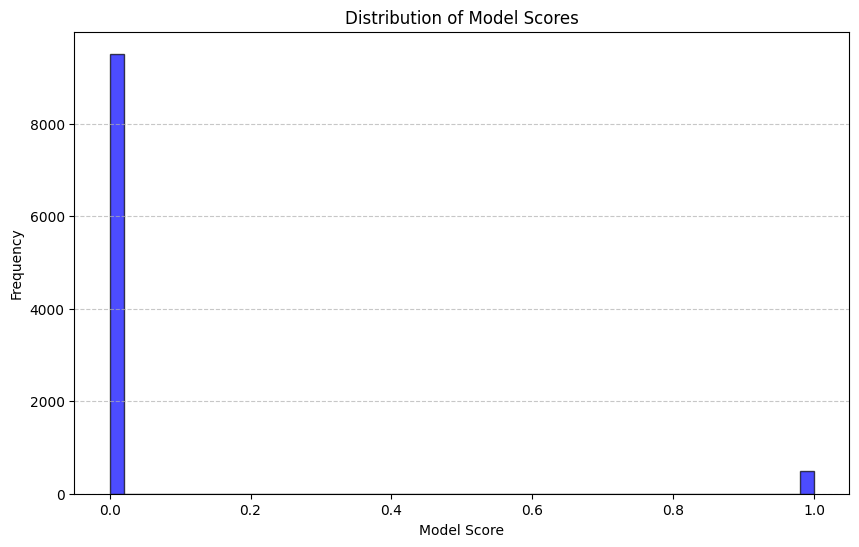

In [51]:
import matplotlib.pyplot as plt

# Plot the distribution of model scores
plt.figure(figsize=(10, 6))
plt.hist(sorted_results['model_score'], bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Model Scores')
plt.xlabel('Model Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Exporting weights:

In [53]:
import numpy as np

bias = model.intercept_[0]
weights = model.coef_.flatten()

print(f"const double MODEL_BIAS = {bias:.6f};")

weights_str = ", ".join([f"{w:.6f}" for w in weights])
print(f"const std::vector<double> MODEL_WEIGHTS = {{ {weights_str} }};")

const double MODEL_BIAS = 0.089569;
const std::vector<double> MODEL_WEIGHTS = { 0.047031, -0.153150, 1.893471, -0.015325, -0.001727, 0.225637, 0.007572, -0.002103, -0.002127, -0.062407, -0.004966, -0.006599, -0.012461, -0.007425, -0.002806, 0.039802, 0.031469, -0.006543, -0.024752, -0.005200, -0.029102, -0.005941, 0.000000, -0.002429, 0.001551, -0.027102, -0.000534, 0.007684, -0.003647, -0.001618, -0.021270, -0.005326, -0.007604, 0.203400, -0.003838, -0.001971, -0.000948, -0.003537, -0.007968, 0.016497, -0.001985, -0.010716, 0.224067, 0.000000, -0.000512, -0.009520, -0.017539, 0.001158, 0.000921, 0.029776, -0.010810, -0.004601, -0.019260, -0.012805, -0.007986, -0.017220, -0.038352, 0.033913, -0.002890, -0.010444, -0.008648, -0.047264, 0.217672, -0.009129, -0.005261, 0.025970, -0.002167, -0.008986, 0.011559, 0.204528, -0.001759, -0.003445, 0.023438, -0.010181, -0.004765, -0.002403, -0.002214, -0.002559, -0.004956, -0.006570, 0.010329, -0.008889, 0.035506, -0.002080, 0.003679, -0.003724,